Imports

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

Load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/IMDB_Project2"
file_path = os.path.join(project_path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Exploration

Missing values:
review       0
sentiment    0
dtype: int64

Duplicates: 418

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


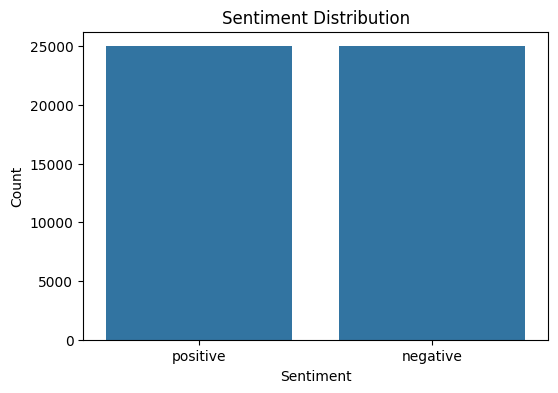

In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nClass distribution:")
print(df["sentiment"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Text Cleaning

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review_clean"] = df["review"].astype(str).apply(clean_text)

print(df[["review", "review_clean"]].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        review_clean  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically there s a family where a little boy ...  
4  petter mattei s love in the time of money is a...  


Label Encoding

In [5]:
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})

assert df["label"].isnull().sum() == 0, "Label mapping failed!"

print(df[["sentiment", "label"]].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


Tokenization

In [6]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["review_clean"])

X = tokenizer.texts_to_sequences(df["review_clean"])
X = pad_sequences(X, maxlen=max_len)

y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 200)
y shape: (50000,)


Dataset split

In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_trainval
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (32000, 200)
Validation shape: (8000, 200)
Test shape: (10000, 200)


Build GRU Model

In [8]:
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# GRU layer
model.add(GRU(64, dropout=0.3, recurrent_dropout=0.3))

# Dense layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.6))

# Output layer
model.add(Dense(1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
#compile model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train Model

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 163s 319ms/step - accuracy: 0.6865 - loss: 0.5820 - val_accuracy: 0.7564 - val_loss: 0.4910 - learning_rate: 5.0000e-04
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 153s 305ms/step - accuracy: 0.8221 - loss: 0.4176 - val_accuracy: 0.8086 - val_loss: 0.4164 - learning_rate: 5.0000e-04
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 304ms/step - accuracy: 0.8605 - loss: 0.3523 - val_accuracy: 0.8229 - val_loss: 0.3897 - learning_rate: 5.0000e-04
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 304ms/step - accuracy: 0.8853 - loss: 0.3004 - val_accuracy: 0.8479 - val_loss: 0.3513 - learning_rate: 5.0000e-04
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 159s 318ms/step - accuracy: 0.9094 - loss: 0.2444 - val_accuracy: 0.8645 - val_loss: 0.3237 - learning_rate: 5.0000e-04


Plot curves

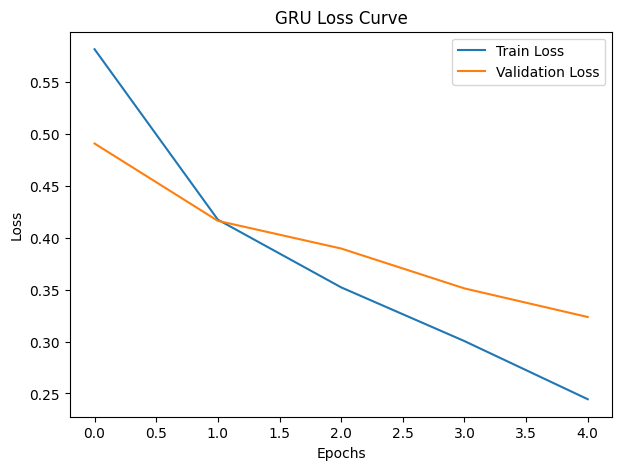

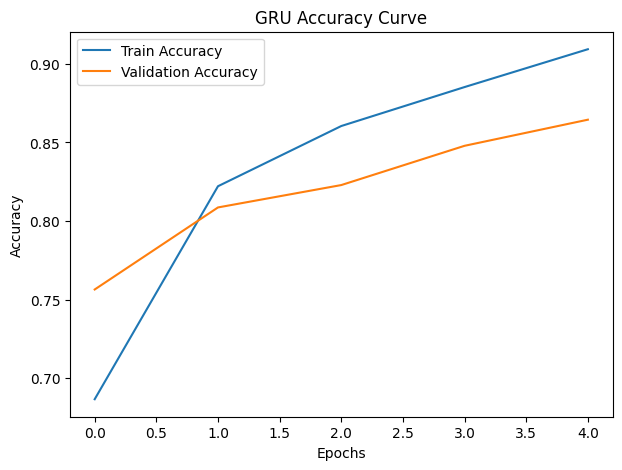

In [11]:
os.makedirs("results", exist_ok=True)

# Loss curve
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("GRU Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("results/gru_loss_curve.png")
plt.show()

# Accuracy curve
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("GRU Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("results/gru_accuracy_curve.png")
plt.show()

Evaluate on Test Set

In [12]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

test_accuracy = np.mean(y_pred.flatten() == y_test)
print("Test Accuracy:", test_accuracy)

report = classification_report(y_test, y_pred)
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step
Test Accuracy: 0.8666
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      5000
           1       0.87      0.86      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



Confusion Matrix

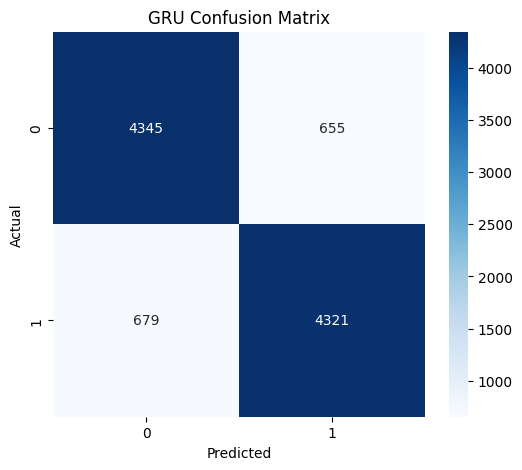

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/gru_confusion_matrix.png")
plt.show()

Save the results

In [14]:
with open("results/gru_metrics.txt", "w") as f:
    f.write("Test Accuracy: {:.4f}\n\n".format(test_accuracy))
    f.write(report)

model.save("results/gru_model.h5")

print("Saved matrices")

Saved matrices
